# ViT Fine-Tuning for Brain Tumor Classification

This notebook fine-tunes `google/vit-base-patch16-224-in21k` on the brain tumor dataset. Data loading and preprocessing are identical to the PDSCNN pipeline.

# PDSCNN — Standalone Training (50 Epochs)

This notebook trains **only the PDSCNN branch** (no ViT, no RRELM, no fusion) from scratch, targeting the highest achievable standalone accuracy on the 4-class brain tumor MRI task (`glioma`, `meningioma`, `notumor`, `pituitary`).

Because the data is pooled from **multiple sources**, the preprocessing pipeline is built to remove cross-source inconsistency before the model ever sees the data:

| Stage | Purpose |
|---|---|
| 1. Source-aware loading | Merges `data.zip`, `data1.zip`, and `data2.zip` class-wise, tagging every image with which zip it came from |
| 2. Deduplication (perceptual hashing) | Removes exact/near-duplicate images that different sources often share, which would otherwise leak across train/val/test |
| 2a. Quality gate | Drops corrupt, unreadably small, blurry, or blank/low-information images before anything is selected for training |
| 2b. Strict fixed-size selection | From the deduped, quality-passed pool, keeps exactly the **12,500** most-unique images (class-balance preserving) |
| 3. Grayscale standardization | MRI scans should carry no color information; forces every source onto the same footing |
| 4. Brain-region autocrop | Strips black borders / scanner annotations that differ by source |
| 5. Denoising | Reduces scanner-specific sensor noise |
| 6. CLAHE | Normalizes contrast differences between scanners/sources |
| 7. Resize to 224×224 | Uniform input size |
| 8. Dataset-specific normalization | Mean/std computed on *this* processed dataset (not ImageNet, since PDSCNN trains from scratch) |
| 9. Augmentation (train only) | Flips, rotation, translation, zoom, brightness/contrast jitter |

Every preprocessing stage below shows before/after images so you can sanity-check it on your own data before committing to a 50-epoch run.

**Outputs saved to Google Drive:** best checkpoint, final checkpoint, full config (class map + normalization stats), training curves, confusion matrix, and the processed image cache.


## 0. Setup

In [ ]:
!pip install -q imagehash grad-cam >/dev/null
print("Installed extra deps: imagehash, grad-cam")


Installed extra deps: imagehash, grad-cam


In [ ]:
import os, glob, shutil, random, zipfile, json, time, hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                              confusion_matrix, classification_report)

import imagehash

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)
if device.type == 'cuda':
    print("GPU:", torch.cuda.get_device_name(0))

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True


Device: cuda
GPU: Tesla T4


## 1. Load Preprocessed Data

Loading the preprocessed images directly from Google Drive.

In [ ]:
from google.colab import drive
import os, glob
import pandas as pd
import shutil

drive.mount('/content/drive')

DRIVE_PROCESSED_ROOT = '/content/drive/MyDrive/processed_data_vit'
LOCAL_PROCESSED_ROOT = '/content/processed_data_vit'

# Copy the processed data to the fast local disk of the Colab instance to prevent I/O bottlenecks during training
if not os.path.exists(LOCAL_PROCESSED_ROOT):
    print("Copying data from Google Drive to local disk for faster training... This may take a minute or two.")
    shutil.copytree(DRIVE_PROCESSED_ROOT, LOCAL_PROCESSED_ROOT)
    print("Copy complete!")

CLASS_NAMES = ['glioma', 'meningioma', 'notumor', 'pituitary']
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}

records = []
for cls in CLASS_NAMES:
    cls_dir = os.path.join(LOCAL_PROCESSED_ROOT, cls)
    if os.path.exists(cls_dir):
        for fname in os.listdir(cls_dir):
            if fname.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff', '.bmp')):
                records.append({'processed_path': os.path.join(cls_dir, fname), 'label': cls})

df = pd.DataFrame(records)
print(f"Loaded {len(df)} preprocessed images directly from {LOCAL_PROCESSED_ROOT}")
print(df['label'].value_counts())



In [ ]:
def compute_mean_std(paths, sample_size=1500):
    if len(paths) > sample_size:
        paths = random.sample(list(paths), sample_size)
    pixel_sum = np.zeros(3)
    pixel_sq_sum = np.zeros(3)
    n_pixels = 0
    for p in tqdm(paths, desc="Computing mean/std"):
        arr = np.asarray(Image.open(p).convert('RGB'), dtype=np.float64) / 255.0
        pixel_sum += arr.sum(axis=(0, 1))
        pixel_sq_sum += (arr ** 2).sum(axis=(0, 1))
        n_pixels += arr.shape[0] * arr.shape[1]
    mean = pixel_sum / n_pixels
    std = np.sqrt(pixel_sq_sum / n_pixels - mean ** 2)
    return mean.tolist(), std.tolist()

DATASET_MEAN, DATASET_STD = compute_mean_std(df['processed_path'].tolist())
print("Dataset mean:", DATASET_MEAN)
print("Dataset std :", DATASET_STD)


Computing mean/std:   0%|          | 0/1500 [00:00<?, ?it/s]

Dataset mean: [0.28974405298583517, 0.28974405298583517, 0.28974405298583517]
Dataset std : [0.23966923371454044, 0.23966923371454044, 0.23966923371454044]


## 5. Train / Val / Test Split

Stratified by class on the deduplicated, preprocessed dataframe (70/15/15).


In [ ]:
train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df['label'], random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df['label'], random_state=SEED)

print("Train:", len(train_df), "| Val:", len(val_df), "| Test:", len(test_df))
print("\nTrain class balance:\n", train_df['label'].value_counts(normalize=True).round(3))


Train: 6363 | Val: 1364 | Test: 1364

Train class balance:
 label
glioma        0.306
notumor       0.245
pituitary     0.230
meningioma    0.219
Name: proportion, dtype: float64


## 6. Augmentation & Dataset/DataLoader

Since heavy preprocessing is already cached, only fast, on-the-fly augmentation happens per epoch: horizontal flip, small rotation, translation/zoom, and mild brightness/contrast jitter. Only the training split is augmented; val/test just get resized + normalized.


In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 64

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(12),
    transforms.RandomAffine(degrees=0, translate=(0.06, 0.06), scale=(0.92, 1.08)),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(DATASET_MEAN, DATASET_STD),
    transforms.RandomErasing(p=0.15, scale=(0.02, 0.08)),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(DATASET_MEAN, DATASET_STD),
])

class BrainTumorDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['processed_path']).convert('RGB')
        label = CLASS_TO_IDX[row['label']]
        if self.transform:
            img = self.transform(img)
        return img, label

train_ds = BrainTumorDataset(train_df, train_transform)
val_ds   = BrainTumorDataset(val_df, eval_transform)
test_ds  = BrainTumorDataset(test_df, eval_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True, persistent_workers=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True, persistent_workers=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("Batches — train:", len(train_loader), "val:", len(val_loader), "test:", len(test_loader))



Batches — train: 100 val: 22 test: 22


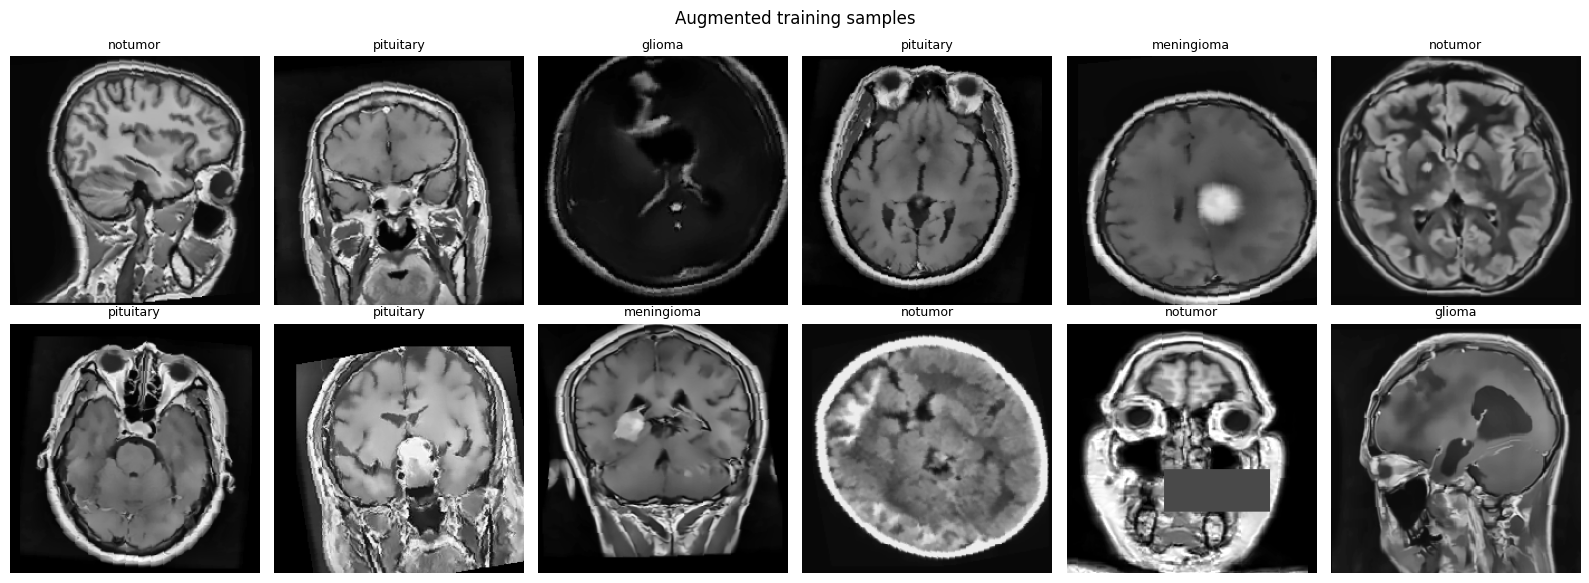

In [ ]:
# Visualize a batch of augmented training images
def denorm(img_tensor):
    img = img_tensor.clone().numpy().transpose(1, 2, 0)
    img = img * np.array(DATASET_STD) + np.array(DATASET_MEAN)
    return np.clip(img, 0, 1)

imgs, labels = next(iter(train_loader))
fig, axs = plt.subplots(2, 6, figsize=(16, 6))
for i, ax in enumerate(axs.flatten()):
    if i >= len(imgs):
        ax.axis('off'); continue
    ax.imshow(denorm(imgs[i]))
    ax.set_title(CLASS_NAMES[labels[i]], fontsize=9)
    ax.axis('off')
plt.suptitle("Augmented training samples")
plt.tight_layout()
plt.show()


## 7. ViT Setup and Fine-tuning

We will use `transformers` to fine-tune `google/vit-base-patch16-224-in21k`.

In [ ]:
!pip install -q transformers
import torch
import torch.nn as nn
from transformers import ViTForImageClassification, ViTConfig
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts

# ViT Configuration
model_name = 'google/vit-base-patch16-224-in21k'
num_classes = len(CLASS_NAMES)

# Load pre-trained ViT
model = ViTForImageClassification.from_pretrained(
    model_name,
    num_labels=num_classes,
    id2label={str(i): c for i, c in enumerate(CLASS_NAMES)},
    label2id={c: str(i) for i, c in enumerate(CLASS_NAMES)}
)

model = model.to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"ViT parameters: {n_params:,}")



config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.weight | UNEXPECTED | 
pooler.dense.bias   | UNEXPECTED | 
classifier.weight   | MISSING    | 
classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


ViT parameters: 85,801,732


In [ ]:
import pandas as pd
from sklearn.utils.class_weight import compute_class_weight

y_train_idx = train_df['label'].map(CLASS_TO_IDX).values
class_weights = compute_class_weight('balanced', classes=np.arange(len(CLASS_NAMES)), y=y_train_idx)
class_weights_t = torch.tensor(class_weights, dtype=torch.float32).to(device)
print("Class weights:", dict(zip(CLASS_NAMES, class_weights.round(3))))

EPOCHS = 50
LR = 2e-5  # Lower LR for fine-tuning transformers
WEIGHT_DECAY = 0.01

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2, eta_min=1e-6)
criterion = nn.CrossEntropyLoss(weight=class_weights_t, label_smoothing=0.1)
scaler = torch.cuda.amp.GradScaler(enabled=(device.type == 'cuda'))

history = {'epoch': [], 'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0

DRIVE_SAVE_DIR = '/content/drive/MyDrive/vit_finetuned'
os.makedirs(DRIVE_SAVE_DIR, exist_ok=True)
BEST_CKPT_PATH = os.path.join(DRIVE_SAVE_DIR, 'vit_best.pth')

for epoch in range(EPOCHS):
    model.train()
    running_loss, running_correct, n_seen = 0.0, 0, 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [train]")

    for imgs, labels in pbar:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()

        with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
            outputs = model(pixel_values=imgs)
            logits = outputs.logits
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * imgs.size(0)
        running_correct += (logits.argmax(1) == labels).sum().item()
        n_seen += imgs.size(0)
        pbar.set_postfix(loss=running_loss / n_seen, acc=running_correct / n_seen)

    train_loss = running_loss / n_seen
    train_acc = running_correct / n_seen

    # Validation
    model.eval()
    val_loss, val_correct, n_val = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
                outputs = model(pixel_values=imgs)
                logits = outputs.logits
                loss = criterion(logits, labels)

            val_loss += loss.item() * imgs.size(0)
            val_correct += (logits.argmax(1) == labels).sum().item()
            n_val += imgs.size(0)

    val_loss /= n_val
    val_acc = val_correct / n_val
    scheduler.step()

    print(f"Epoch {epoch+1}/{EPOCHS} — train_loss {train_loss:.4f} train_acc {train_acc:.4f} "
          f"| val_loss {val_loss:.4f} val_acc {val_acc:.4f} | lr {optimizer.param_groups[0]['lr']:.2e}")

    history['epoch'].append(epoch + 1)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), BEST_CKPT_PATH)
        print(f"  -> New best val_acc {val_acc:.4f}, checkpoint saved!")

print(f"Training complete. Best Validation Accuracy: {best_val_acc:.4f}")
pd.DataFrame(history).to_csv(os.path.join(DRIVE_SAVE_DIR, 'vit_history.csv'), index=False)



/tmp/ipykernel_2157/3749939364.py:16: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type == 'cuda'))


Class weights: {'glioma': np.float64(0.817), 'meningioma': np.float64(1.143), 'notumor': np.float64(1.022), 'pituitary': np.float64(1.085)}


Epoch 1/50 [train]:   0%|          | 0/100 [00:00<?, ?it/s]

/tmp/ipykernel_2157/3749939364.py:34: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
/tmp/ipykernel_2157/3749939364.py:59: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):


Epoch 1/50 — train_loss 0.9414 train_acc 0.7588 | val_loss 0.6469 val_acc 0.8944 | lr 1.95e-05
  -> New best val_acc 0.8944, checkpoint saved!


...

Epoch 48/50 — train_loss 0.3575 train_acc 0.9980 | val_loss 0.3990 val_acc 0.9831 | lr 1.20e-05


Epoch 49/50 [train]:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 49/50 — train_loss 0.3606 train_acc 0.9965 | val_loss 0.3920 val_acc 0.9861 | lr 1.12e-05


Epoch 50/50 [train]:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 50/50 — train_loss 0.3566 train_acc 0.9989 | val_loss 0.3916 val_acc 0.9853 | lr 1.05e-05
Training complete. Best Validation Accuracy: 0.9868


## 8. Test Set Evaluation

In [ ]:
# Load best model for evaluation
model.load_state_dict(torch.load(BEST_CKPT_PATH))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc="Evaluating on test set"):
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(pixel_values=imgs)
        preds = outputs.logits.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

test_acc = accuracy_score(all_labels, all_preds)
print(f"\nTest Accuracy: {test_acc:.4f}")
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))



Evaluating on test set:   0%|          | 0/22 [00:00<?, ?it/s]


Test Accuracy: 0.9875

Classification Report:
              precision    recall  f1-score   support

      glioma       0.99      0.99      0.99       418
  meningioma       0.98      0.98      0.98       299
     notumor       0.99      0.99      0.99       333
   pituitary       0.99      0.99      0.99       314

    accuracy                           0.99      1364
   macro avg       0.99      0.99      0.99      1364
weighted avg       0.99      0.99      0.99      1364

